In [40]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle
import importlib

import subcluster_funcs as funcs
importlib.reload(funcs)
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)
plots_dir = "plots_dir/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
cell_type = "Fibroblast"

In [4]:
%%time
adata = sc.read_h5ad("../continuous_cov_corrected_no_scvi/" + cell_type  + ".h5ad")

CPU times: user 4min 7s, sys: 35.4 s, total: 4min 43s
Wall time: 7min 4s


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

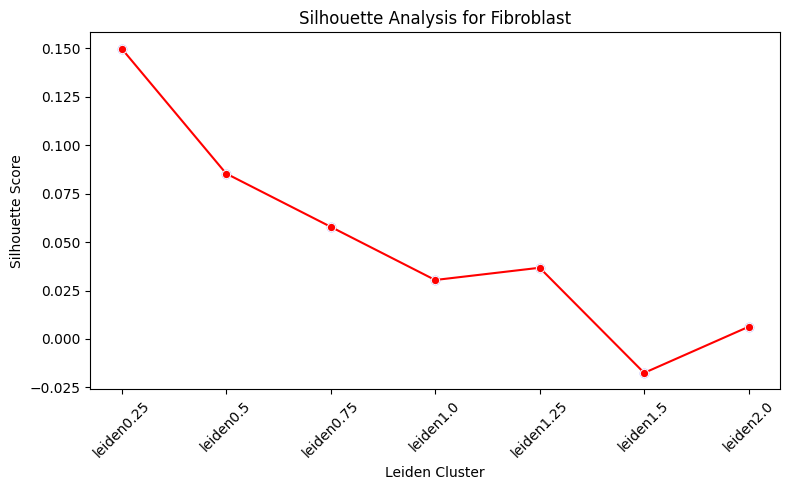

In [5]:
funcs.silhouette(adata, silhouette_res_dir = "../silhouette_res_scVI/", cell_type = cell_type)

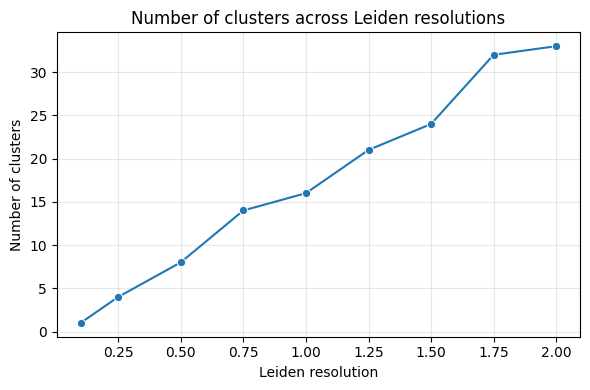

In [6]:
cluster_df, fig = funcs.leiden_resolution_summary(adata)

### Use Leiden 0.5

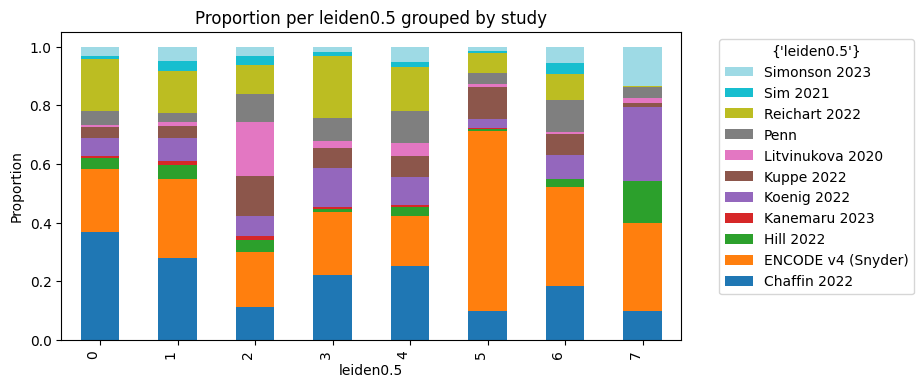

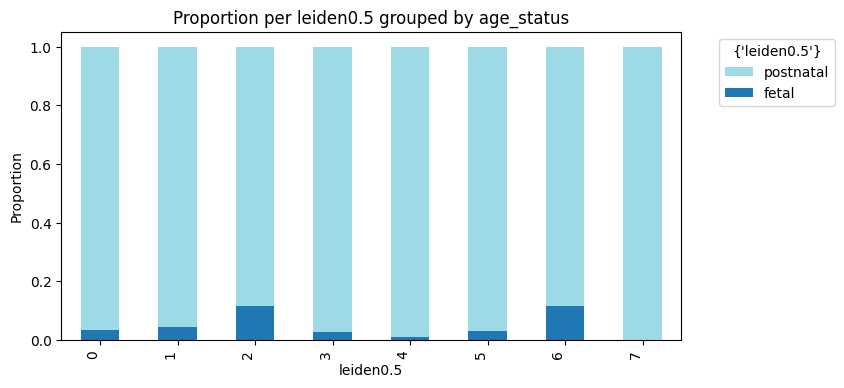

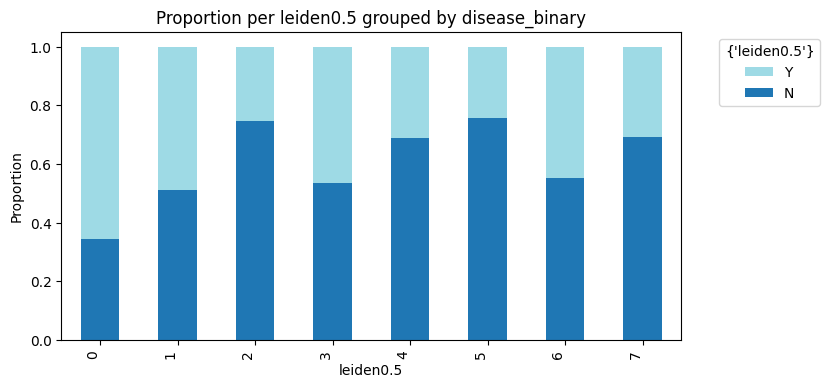

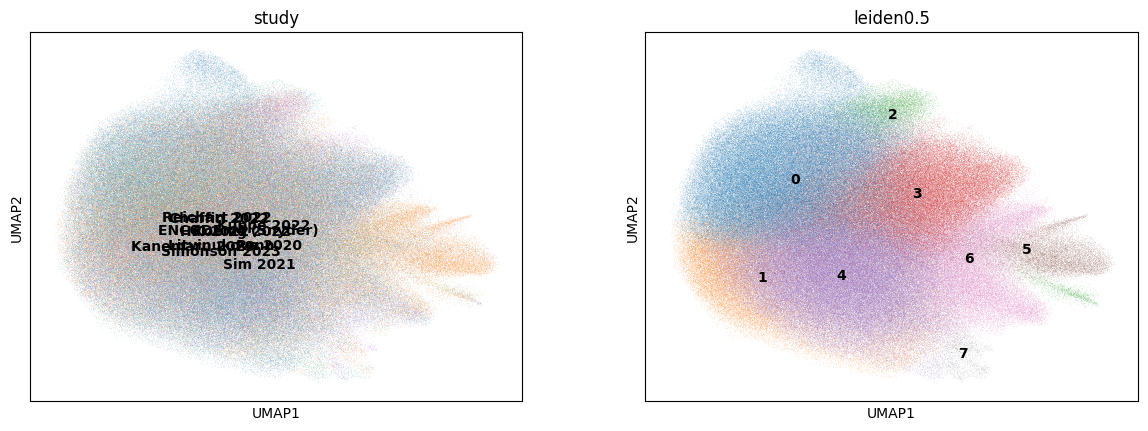

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

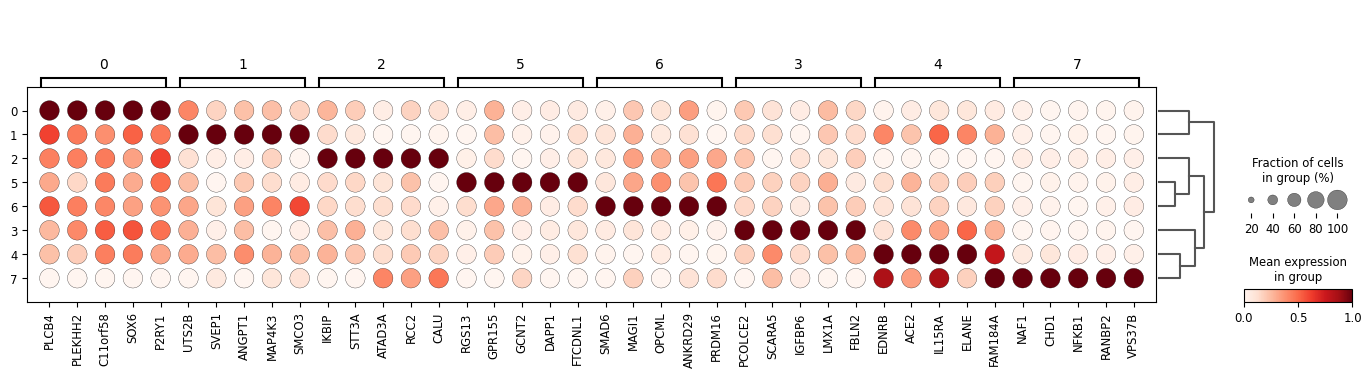

Counter({'0': 166237, '4': 161552, '3': 85380, '1': 50500, '6': 49748, '5': 21249, '2': 12185, '7': 1762})
CPU times: user 3min 46s, sys: 1h 26min 7s, total: 1h 29min 54s
Wall time: 1min 54s


['leiden0.5',
 AnnData object with n_obs × n_vars = 548613 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'l

In [7]:
%%time
leiden_key = "leiden0.5"
funcs.specify_leiden_subclustering(adata=adata, leiden=leiden_key)

In [8]:
Counter(adata.obs[leiden_key])

Counter({'0': 166237,
         '4': 161552,
         '3': 85380,
         '1': 50500,
         '6': 49748,
         '5': 21249,
         '2': 12185,
         '7': 1762})

In [9]:
adata.obs['age_disease'] = adata.obs['age_status'].astype(str) + ":" + adata.obs['disease'].astype(str)

Subsampling fetal:ND: 19818 -> 10000 cells
Subsampling postnatal:AMI: 14735 -> 10000 cells
Subsampling postnatal:ARVC: 16118 -> 10000 cells
Subsampling postnatal:DCM: 129913 -> 10000 cells
Subsampling postnatal:HCM: 57740 -> 10000 cells
Subsampling postnatal:ICM: 19568 -> 10000 cells
Keeping all 1611 cells for postnatal:NCCM
Subsampling postnatal:ND: 274170 -> 10000 cells
Subsampling postnatal:pediatric HF: 14940 -> 10000 cells


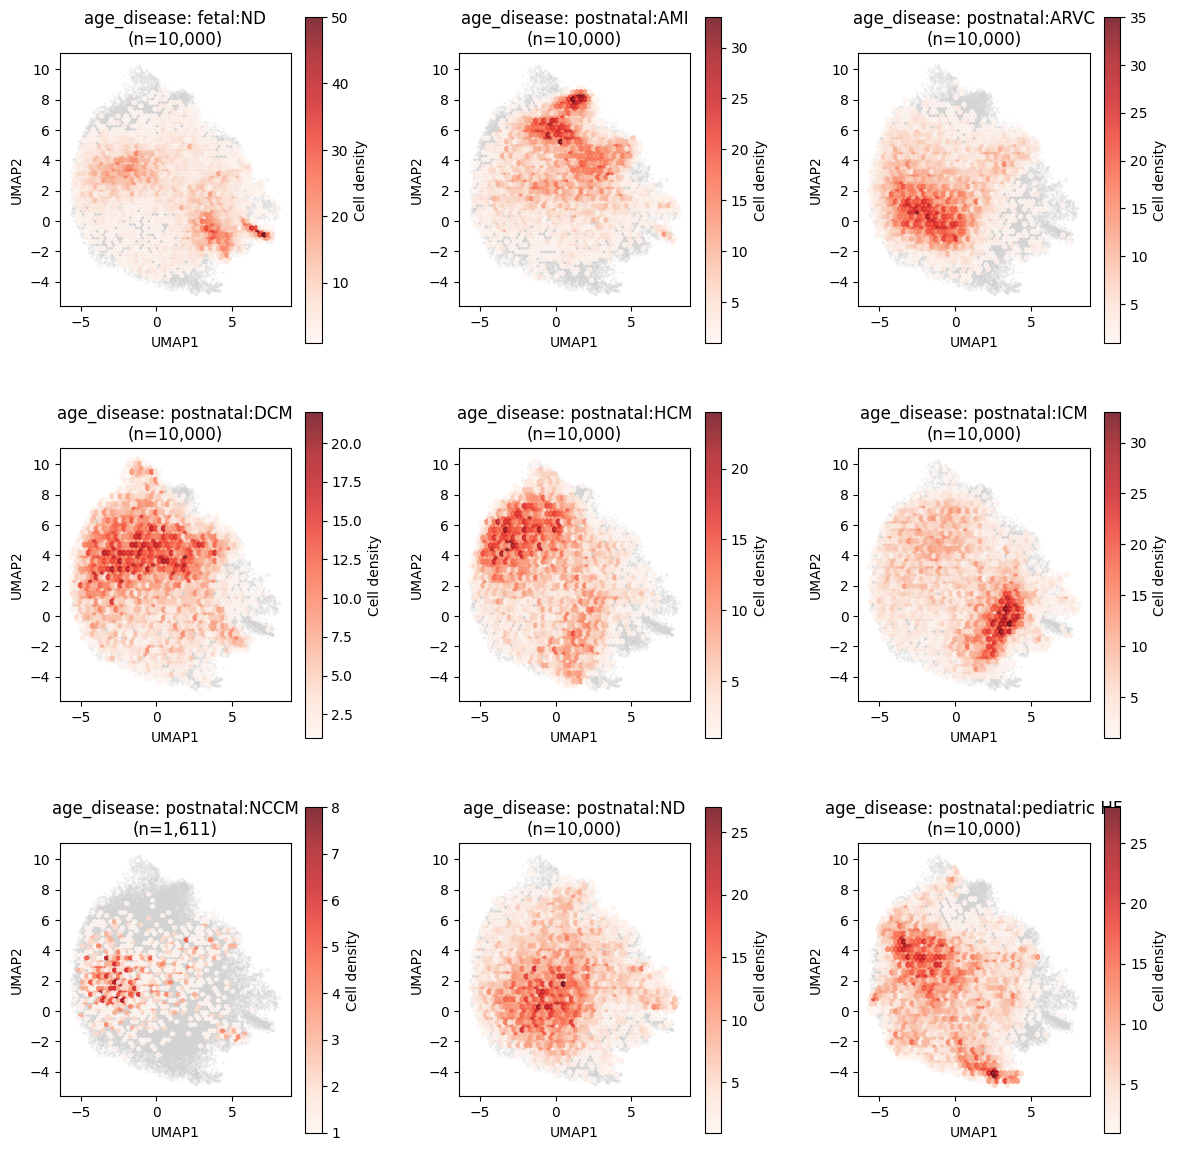

CPU times: user 8.54 s, sys: 15.3 s, total: 23.9 s
Wall time: 23.7 s


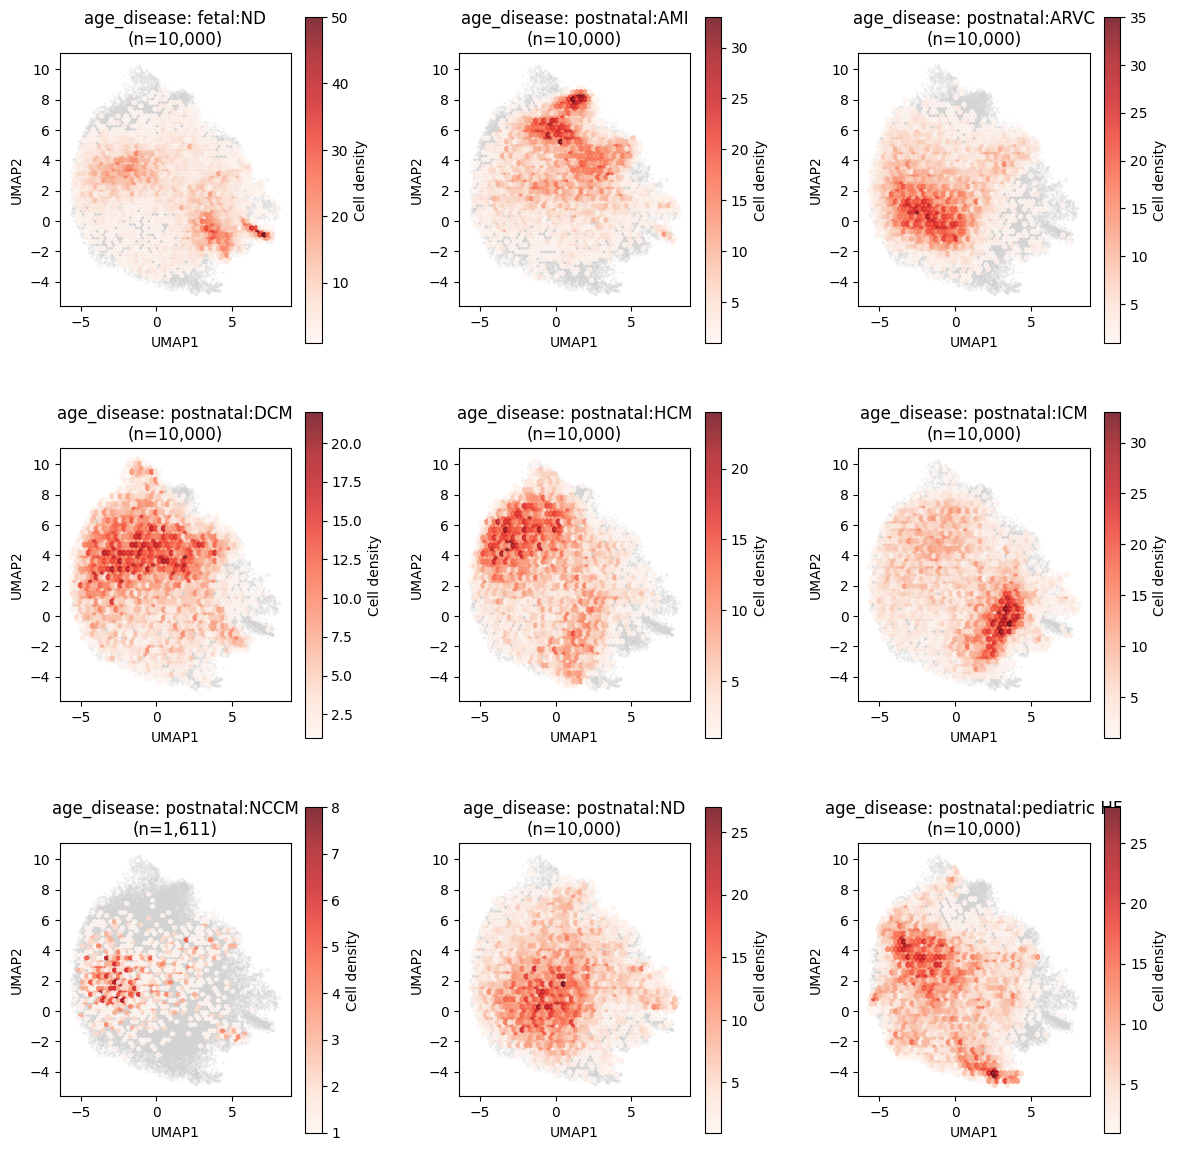

In [41]:
%%time
funcs.plot_umap_by_cluster(adata, metadata_key='age_disease', max_per_condition=10000, gridsize=50, ncols=3)

Subsampling Chaffin 2022: 147547 -> 10000 cells
Subsampling ENCODE v4 (Snyder): 127860 -> 10000 cells
Subsampling Hill 2022: 16701 -> 10000 cells
Keeping all 3474 cells for Kanemaru 2023
Subsampling Koenig 2022: 47663 -> 10000 cells
Subsampling Kuppe 2022: 33150 -> 10000 cells
Subsampling Litvinukova 2020: 13574 -> 10000 cells
Subsampling Penn: 41359 -> 10000 cells
Subsampling Reichart 2022: 85699 -> 10000 cells
Keeping all 9716 cells for Sim 2021
Subsampling Simonson 2023: 21870 -> 10000 cells


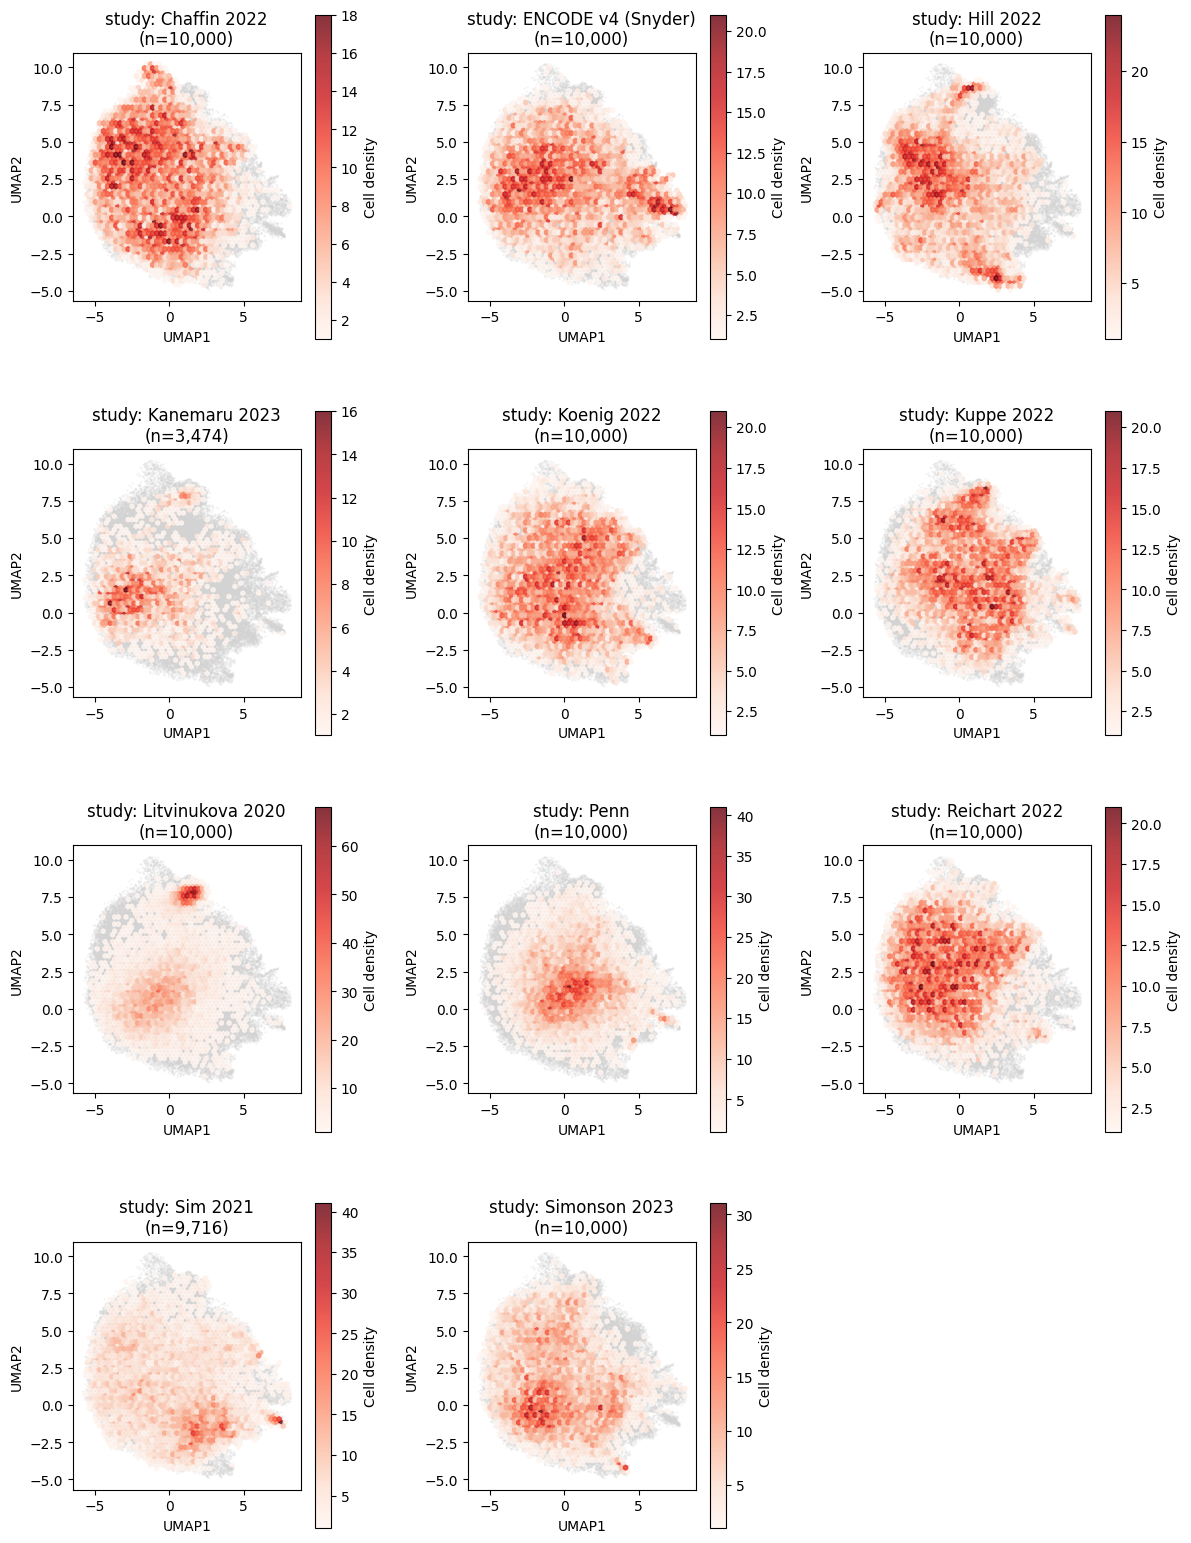

CPU times: user 7.41 s, sys: 5.47 s, total: 12.9 s
Wall time: 12.6 s


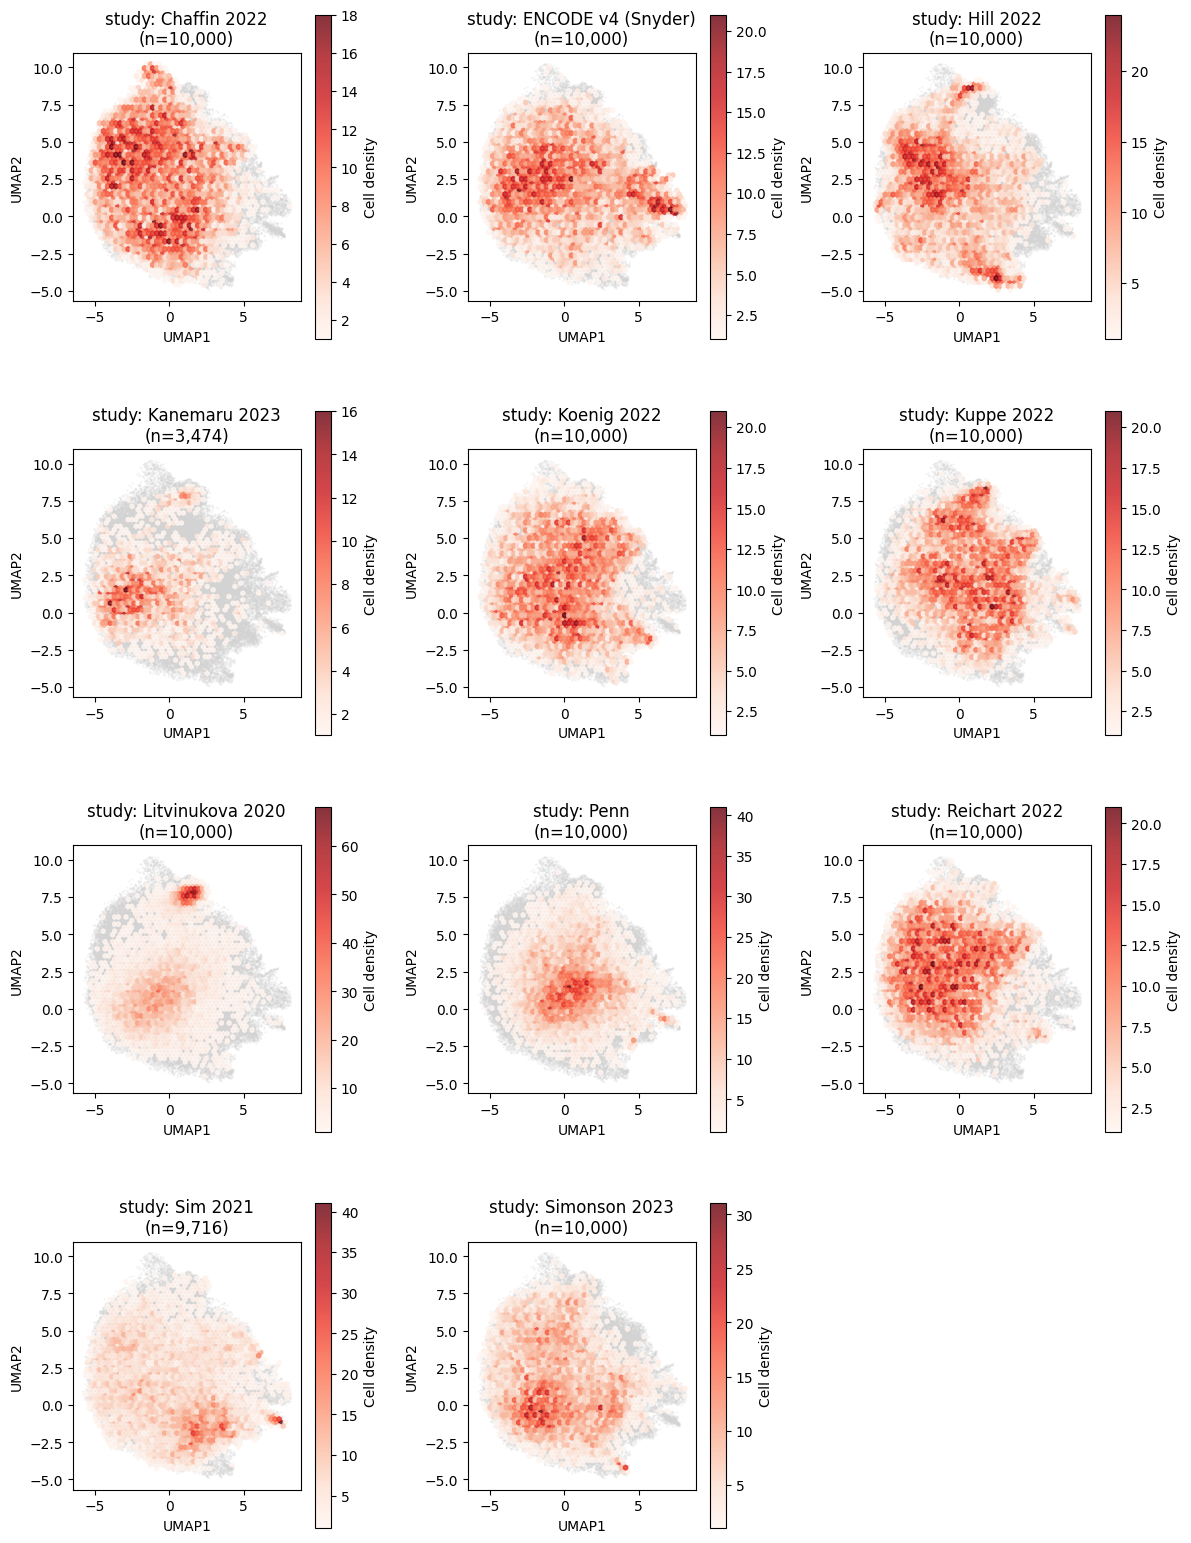

In [43]:
%%time
funcs.plot_umap_by_cluster(adata, metadata_key='study', max_per_condition=10000, gridsize=50, ncols=3)

Subsampling 0: 166237 -> 10000 cells
Subsampling 1: 50500 -> 10000 cells
Subsampling 2: 12185 -> 10000 cells
Subsampling 3: 85380 -> 10000 cells
Subsampling 4: 161552 -> 10000 cells
Subsampling 5: 21249 -> 10000 cells
Subsampling 6: 49748 -> 10000 cells
Keeping all 1762 cells for 7


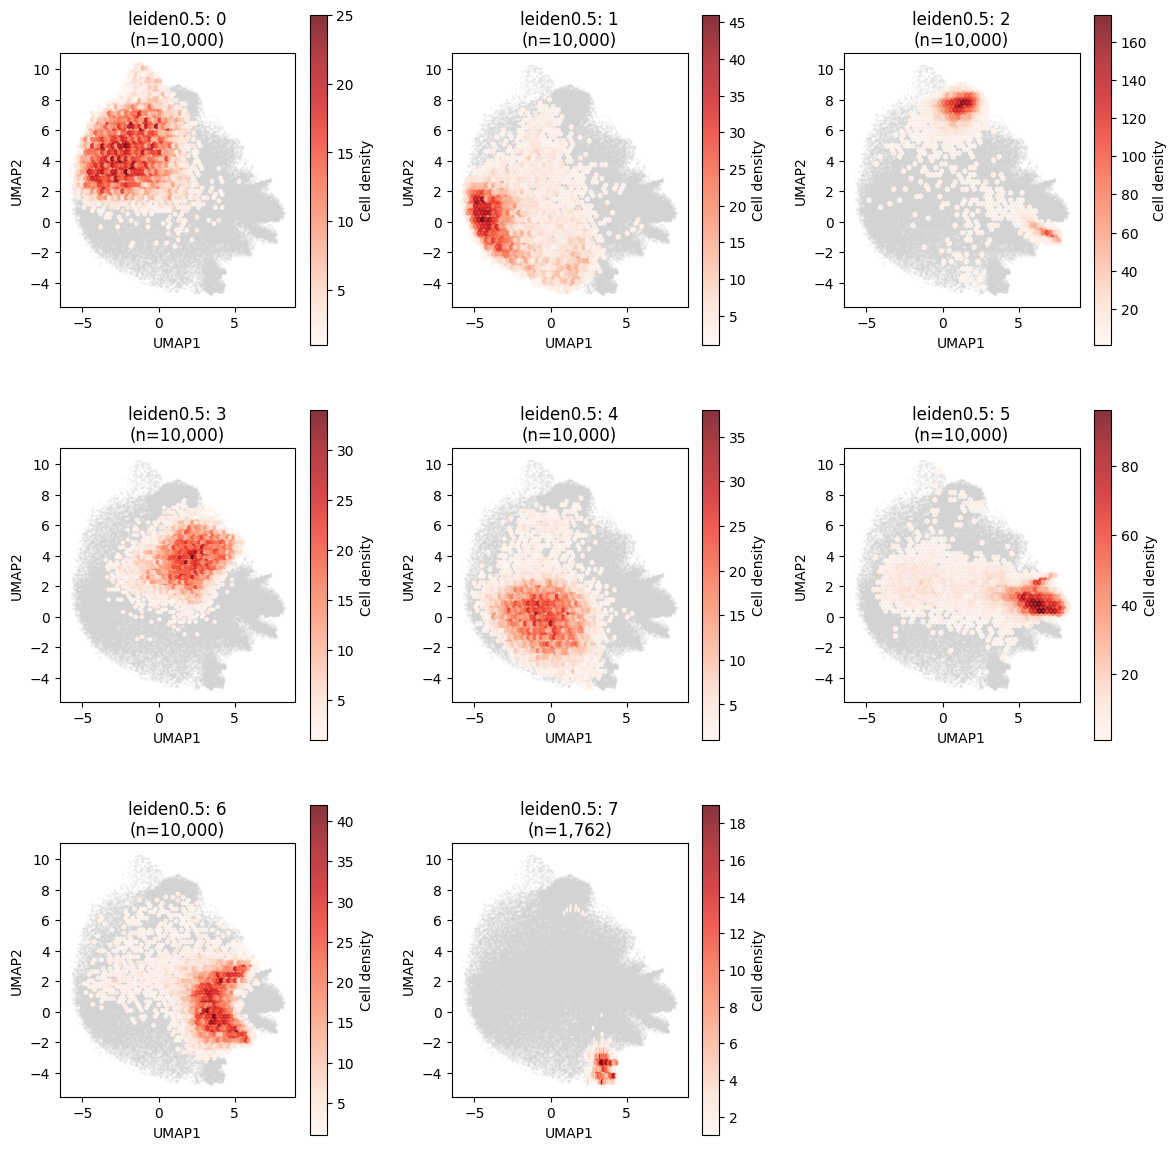

CPU times: user 8.78 s, sys: 21.8 s, total: 30.6 s
Wall time: 30.4 s


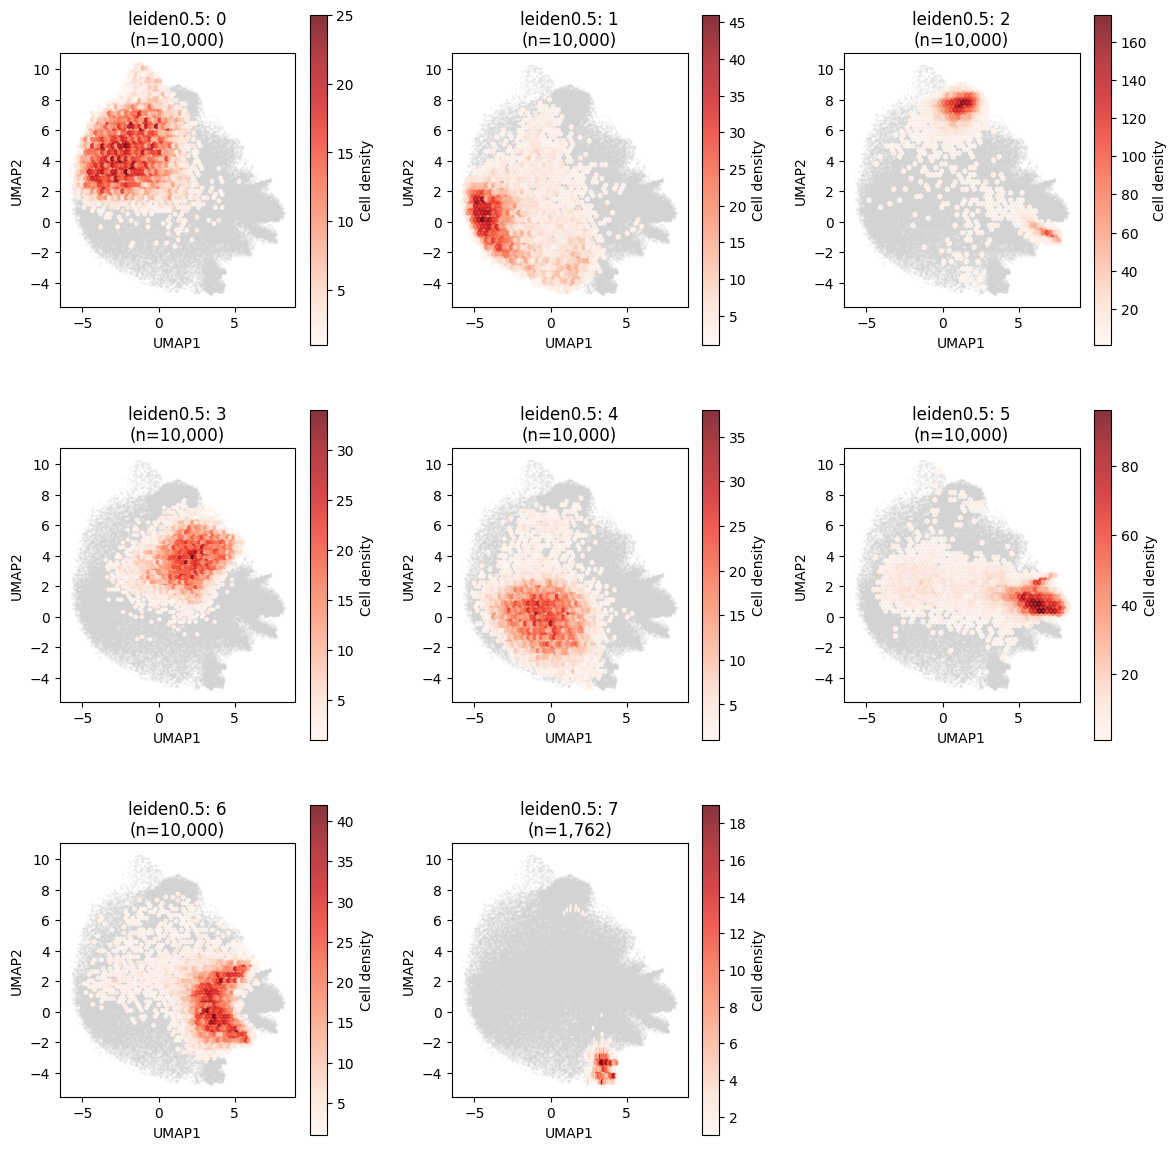

In [46]:
%%time
funcs.plot_umap_by_cluster(adata, metadata_key = leiden_key, max_per_condition=10000, gridsize=50, ncols=3)

### Examine enrichment along metadata categories

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


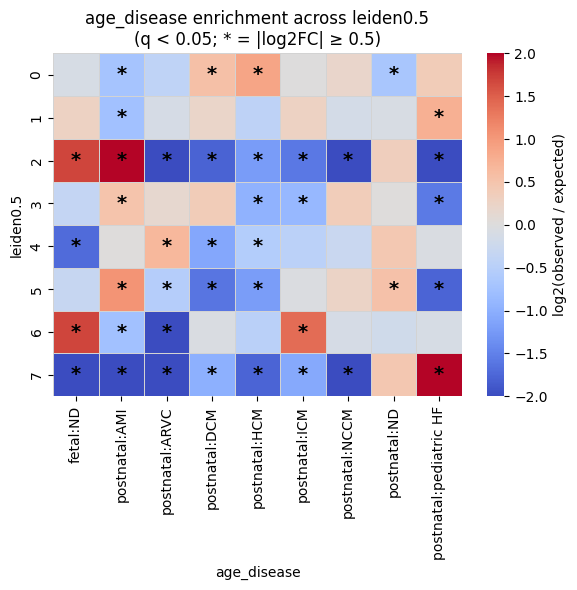

In [13]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=adata.obs,
    cluster_label=leiden_key,
    study_col="age_disease",
    min_cells=50, figsize_tuple = (6,6)
)

### Marker gene / ORA analysis

In [102]:
#sc.get.rank_genes_groups_df(adata, group="0").head(60)['names']

Processing Cluster 0... Success.
Processing Cluster 1... Success.
Processing Cluster 2... Success.
Processing Cluster 3... Success.
Processing Cluster 4... Success.
Processing Cluster 5... Success.
Processing Cluster 6... Success.
Processing Cluster 7... Success.


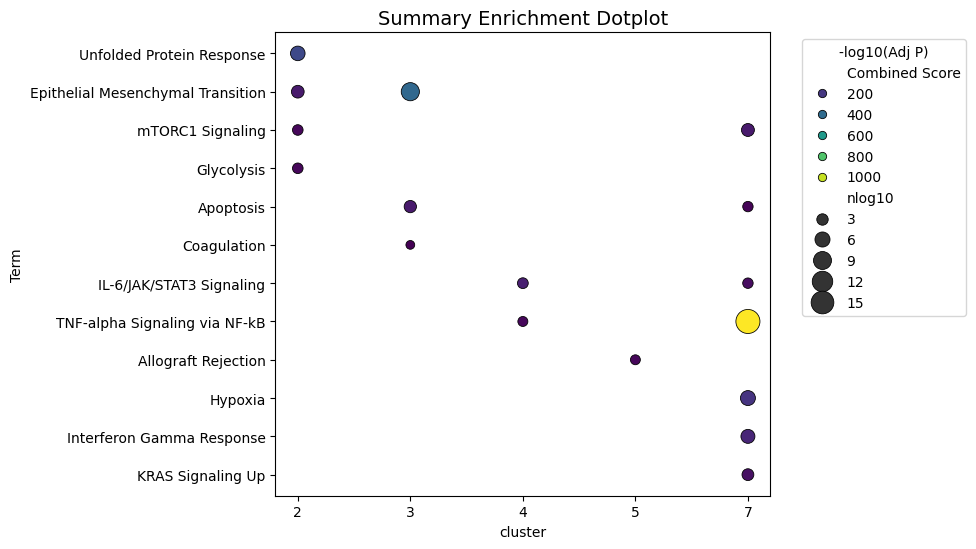

In [15]:
funcs.plot_all_cluster_enrichment(
     adata, cluster_key=leiden_key, 
     gene_sets=["MSigDB_Hallmark_2020"], outdir=None,top_n=100)

In [ ]:
#sc.pl.umap(adata, color=["POSTN", "FAP"], cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True),
#    vmin=0, vmax="p99")

In [ ]:
#sc.pl.umap(adata, color=["PCOLCE2", "FBLN2", "ACKR4", "CD81"], cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True),
#    vmin=0, vmax="p99")

#sc.pl.umap(adata, color=["SVEP1", "PDGFD", "ANGPT1"], cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True),
#    vmin=0, vmax="p99")

In [96]:
#sc.pl.umap(adata, color=["PRDM16", "SMAD6", "SMAD7"], cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True),
#    vmin=0, vmax="p99")

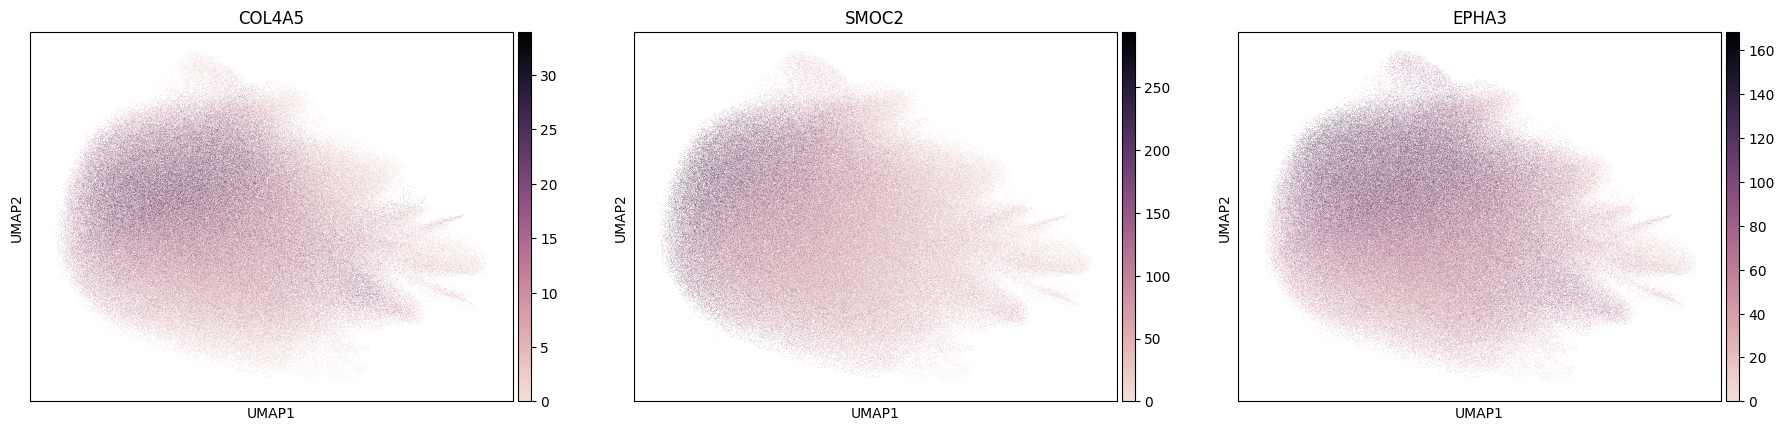

In [103]:
#sc.pl.umap(adata, color=["COL4A5", "SMOC2", "EPHA3"], cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True),
#    vmin=0, vmax="p99")

- Cluster 0 are enriched in DCM/HCM (SMOC2/EMILIN3/COL4A5)
- Cluster 1 are perivascular (ANGPT1/CCBE1/SVEP1/FBLN5; PDGFD recruits pericytes/vSMC)
- Cluster 2 are activated (POSTN/FAP/TNC)
- Cluster 3 are interstitial, ECM-producing fibroblasts (PCOLCE2/FBN1/MFAP4/LTBP4)
- Cluster 4 is enriched in non-diseased, with many paracrine signals (EDNRB/ACE2/BMPER/FGF10/FGF7)
- Cluster 5 show some myeloid contamination; remove this 
- Cluster 6 are anti-fibrotic fibroblasts, with expression of TGF-beta inhibitors (SMAD6/SMAD7/PRDM16)
- Cluster 7 are inflammatory; enriched in pediatric heart failure (IL6/PTGS2/NFKB1/HAS1/NR4A1/ADAMTS4)

### Subcluster annotation

In [82]:
adata.obs['subcluster'] = adata.obs[leiden_key].map(
    {"0": "DCM_HCM_enriched",
     "1": "Perivascular",
     "2": "Activated",
     "3": "Interstitial",
     "4": "ND_enriched",
     "5": "Myeloid_contamination",
     "6": "Anti_fibrotic",
     "7": "Inflammatory"
    }
)

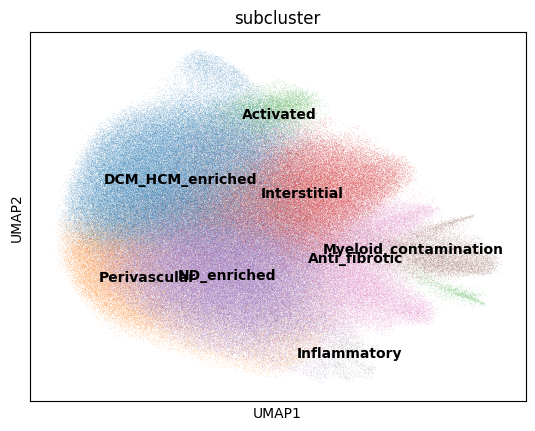

In [83]:
sc.pl.umap(adata, color = "subcluster", legend_loc = "on data")

In [84]:
%%time
filt_adata = adata[adata.obs.subcluster != "Myeloid_contamination"].copy()

CPU times: user 22.4 s, sys: 3min 8s, total: 3min 31s
Wall time: 3min 31s


In [86]:
subcluster_order = [
    "Activated",
    "Anti_fibrotic",
    "DCM_HCM_enriched",
    "ND_enriched",
    "Inflammatory",
    "Interstitial",
    "Perivascular",
]

# convert 'subcluster' column to an ordered categorical type
filt_adata.obs['subcluster'] = pd.Categorical(
    filt_adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

# define colors for each subcluster
subcluster_colors = {
    "DCM_HCM_enriched": "magenta",
    "Inflammatory": "red",        
    "Activated": "yellow",     
    "ND_enriched": "orange",      
    "Perivascular": "purple",       
    "Anti_fibrotic": "blue",
    "Interstitial": "gray"
}

# Assign colors to adata.uns in the same order as subcluster_order
filt_adata.uns['subcluster_colors'] = [subcluster_colors[sc] for sc in subcluster_order]

In [87]:
Counter(filt_adata.obs.subcluster)

Counter({'DCM_HCM_enriched': 166237,
         'ND_enriched': 161552,
         'Interstitial': 85380,
         'Perivascular': 50500,
         'Anti_fibrotic': 49748,
         'Activated': 12185,
         'Inflammatory': 1762})

### Further subclustering for large clusters

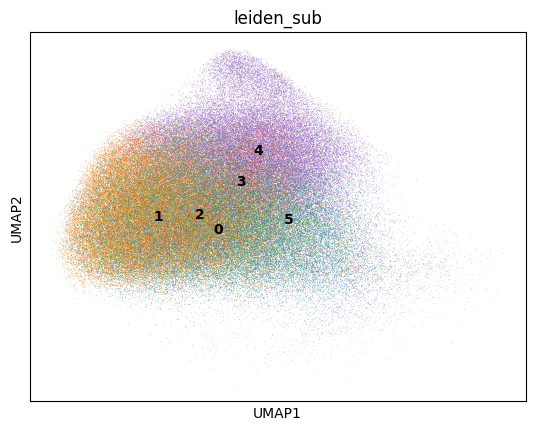

CPU times: user 18.8 s, sys: 35.2 s, total: 54 s
Wall time: 54.2 s


In [32]:
%%time
adata_0 = adata[adata.obs[leiden_key] == '0'].copy()
# re-run UMAP to see the internal structure
sc.tl.leiden(adata_0, flavor="igraph", n_iterations=2, resolution=0.5, 
             key_added = 'leiden_sub')
sc.pl.umap(adata_0, color = "leiden_sub", legend_loc = "on data")
#funcs.specify_leiden_subclustering(adata=adata_6, leiden="leiden_sub")

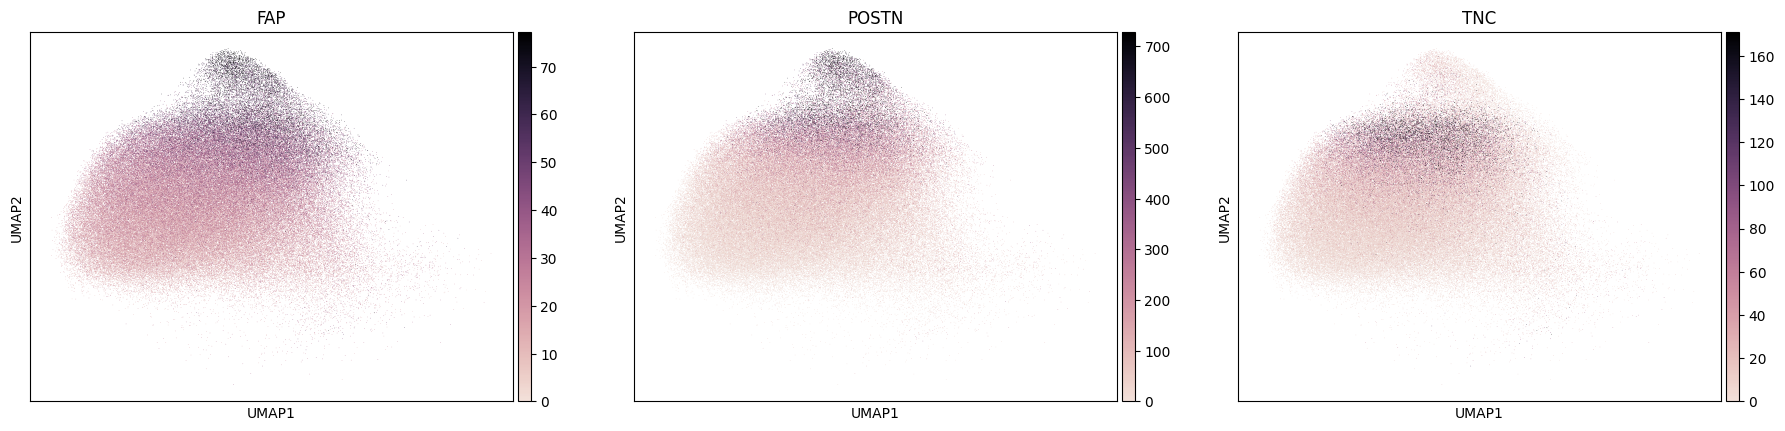

In [70]:
sc.pl.umap(adata_0, color=["FAP", "POSTN", "TNC"], cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True),
    vmin=0, vmax="p99")

In [88]:
adata_0.obs['subcluster'] = (
    adata_0.obs['leiden_sub'].astype(str)
    .map(lambda x: 'Activated' if x in {'4'} else 'DCM_HCM_enriched')
    .astype('category')
)

filt_adata.obs.update(adata_0.obs[['subcluster']])

### Produce plots

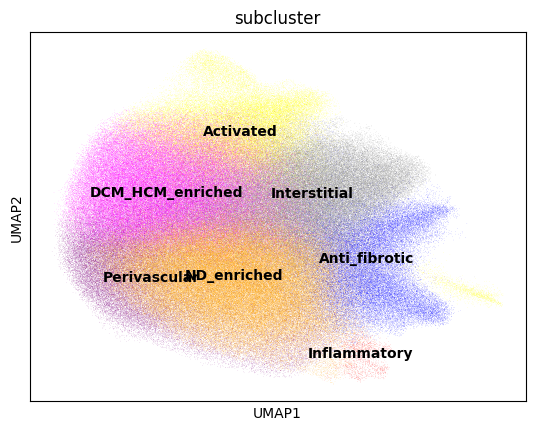

In [89]:
with plt.rc_context(): 
    sc.pl.umap(filt_adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors, show=False)
    plt.savefig(plots_dir + cell_type + "_subclustered.pdf", bbox_inches="tight")

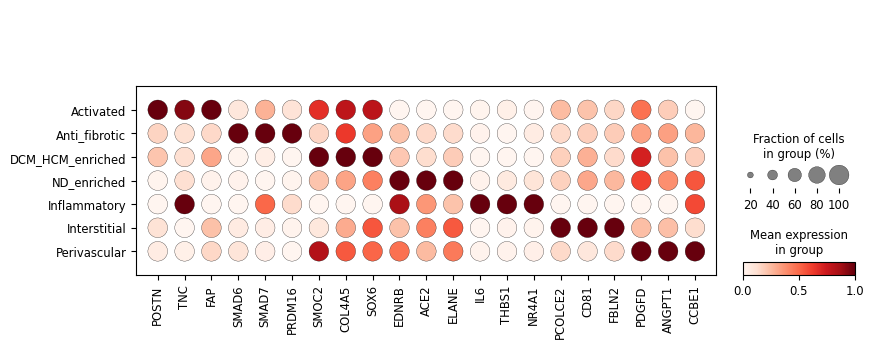

In [107]:
with plt.rc_context(): 
    sc.pl.dotplot(filt_adata, var_names = ["POSTN", "TNC", "FAP", 
                                           "SMAD6", "SMAD7", "PRDM16",
                                           "SMOC2", "COL4A5", "SOX6",
                                           "EDNRB", "ACE2", "ELANE",
                                           "IL6", "THBS1", "NR4A1",
                                           "PCOLCE2", "CD81", "FBLN2",
                                           "PDGFD", "ANGPT1", "CCBE1"], groupby = "subcluster", show=False, standard_scale='var')
    plt.savefig(plots_dir + cell_type + "_subclustered_dotplot.pdf", bbox_inches="tight")

### Show enrichments by disease-age status and age group

In [108]:
adata_metadata = filt_adata.obs

disease_filtered_metadata = adata_metadata[~adata_metadata['age_disease'].isin(["postnatal:ARVC", "postnatal:NCCM"])].copy()
for col in disease_filtered_metadata.select_dtypes('category').columns:
    disease_filtered_metadata[col] = disease_filtered_metadata[col].cat.remove_unused_categories()
    
ND_adata_metadata = adata_metadata[adata_metadata['disease_binary'] == "N"].copy()

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:412: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


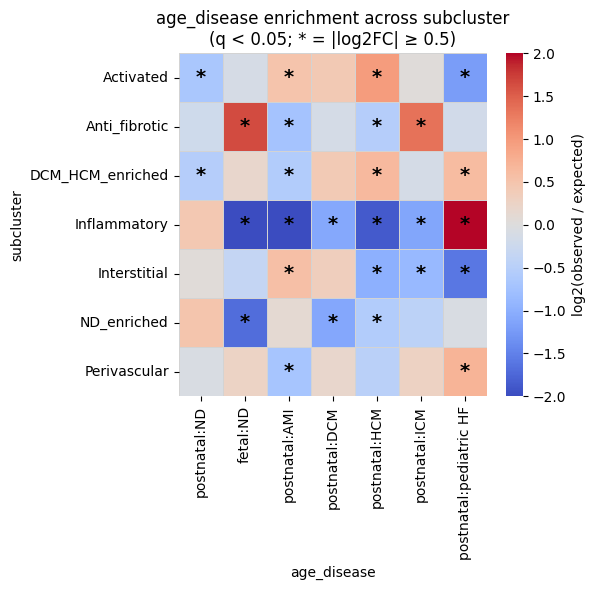

In [109]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=disease_filtered_metadata,
    cluster_label="subcluster",
    study_col="age_disease",
    metadata_order = ['postnatal:ND', 'fetal:ND', 'postnatal:AMI', 'postnatal:DCM', 
                      'postnatal:HCM', 'postnatal:ICM', 'postnatal:pediatric HF'],
    min_cells=50, figsize_tuple = (6,6)
)

plot.savefig(plots_dir + cell_type + "_subcluster_age_disease.pdf")

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:412: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


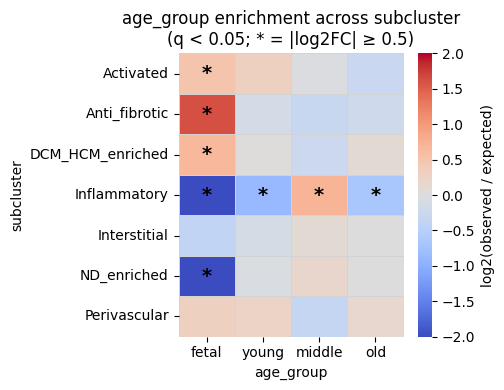

In [110]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=ND_adata_metadata,
    cluster_label="subcluster",
    metadata_order = ["fetal", "young", "middle", "old"],
    study_col="age_group",
    min_cells=50, figsize_tuple = (5,4)
)

plot.savefig(plots_dir + cell_type + "_subcluster_aging.pdf")

In [111]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()
print(subcluster_stats)

              subcluster   count  proportion
0       DCM_HCM_enriched  166237    0.303013
1            ND_enriched  161552    0.294474
2           Interstitial   85380    0.155629
3              Signaling   50500    0.092050
4          Anti_fibrotic   49748    0.090680
5  Myeloid_contamination   21249    0.038732
6              Activated   12185    0.022211
7           Inflammatory    1762    0.003212


### Save metadata and filtered adata

In [112]:
filt_adata.obs.to_csv(post_subclustering_dir + cell_type + "_annotation.csv")

In [113]:
filt_adata.write(post_subclustering_dir + cell_type + ".h5ad")